The fifth notebook in the STORM workflow. Tutorials 3-4 worked with the
**cell embedding** (``X_storm``) — one point per cell, used for clustering and
spatial-domain discovery. This notebook turns to STORM's other learned
representation, the **gene-program activity embedding** (``X_storm_gp``):
every coordinate is one curated gene program, and its value is *how strongly
that program is lit up in each cell*.

The aim here is exploratory. Given a trained model and the preprocessed
P21/P22 mouse-brain AnnDatas, how do you read out and make sense of the
programs the model learned? By the end you will be able to:

1. project cells into the program-activity space (``X_storm_gp``);
2. pull a human-readable summary of each active program — its member genes /
   peaks and their learned weights — and see how *sparse* STORM's programs are;
3. rank programs by how specifically they mark each spatial domain;
4. read all of this off a domain × program activity heatmap, for both the RNA
   and ATAC views.

The richer per-program visualisations (weight-composition bars and the
spatial-activity-across-timepoints panels) live in the companion
[tutorial 6](./tutorial_6_gp_visualization.ipynb), which picks up the tables
this notebook writes out. As in tutorials 3-4, every step re-runs against
whatever ``.dill`` checkpoint ``TRAINED_DILL`` points at.

# STORM tutorial 5: exploring gene-program activities

Where the cell embedding (``X_storm``) is good at telling cells *apart*, the
program-activity embedding is good at telling you *why*. Each axis is a named
biological program — assembled in
[tutorial 1](./tutorial_1_preprocess.ipynb) from OmniPath (ligand–receptor),
NicheNet (ligand–target), MEBOCOST (metabolite–sensor) and CollecTRI
(TF–target), plus a few cell-type marker programs — so a high activity value
is a concrete, inspectable hypothesis rather than an opaque latent dimension.

| Object | What it is |
| --- | --- |
| ``adata.obsm["X_storm_gp"]`` | per-cell program activity; one column per *active* program |
| ``adata.obsm["X_storm_gp_signc"]`` | the same, sign-corrected so positive = "high" (use for heatmaps) |
| ``model.get_gp_summary(...)`` | one row per program: member genes/peaks, learned weights, non-zero counts |

A defining feature of STORM is that its programs are **sparse** — most retain
only a handful of non-zero member features after training — which is exactly
what keeps the activity scores interpretable. Every analysis function used
below lives in :mod:`storm.programs`.

In [1]:
import os
import sys

# Make the in-tree `storm/` package importable without a pip install.
_REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), os.pardir)) \
    if "__file__" in globals() else os.path.abspath(os.path.join(os.getcwd(), os.pardir))
for _candidate in (_REPO_ROOT, os.getcwd()):
    if os.path.isdir(os.path.join(_candidate, "storm")) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)
        break

from itertools import chain

import anndata as ad
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

import storm
from storm.models import load_model
from storm.programs import (
    encode_gp_activity,
    gp_enrichment_test,
    top_gps_per_cluster,
    gp_cluster_heatmap,
)

storm.plot.set_publication_params()

/gpfs/gibbs/project/zhao/xc384/conda_envs/storm/lib/python3.10/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 1. Parameters and paths

**Swap ``TRAINED_DILL`` for a full-length checkpoint** to explore
publication-quality programs — everything below re-runs against whatever model
you load. The remaining paths point at the artifacts written by tutorials 1
and 3.

In [2]:
TUTORIAL_OUT = "../artifacts/storm_tutorial"
PREP_DIR = f"{TUTORIAL_OUT}/preprocessed"
CLUSTER_DIR = f"{TUTORIAL_OUT}/clustered"
GP_DIR = f"{TUTORIAL_OUT}/gp_analysis"
os.makedirs(GP_DIR, exist_ok=True)

PREP_RNA = f"{PREP_DIR}/rna_preprocessed.h5ad"
PREP_ATAC = f"{PREP_DIR}/atac_preprocessed.h5ad"
PREP_GRAPH = f"{PREP_DIR}/guidance.graphml.gz"

# >>> Change this to point at your full-length training checkpoint. <<<
TRAINED_DILL = "../dill_files/FINE_storm_P21P22_reftarg160_2tmp_RNAr_peak_source_repro.dill"

# How many of the most domain-specific programs to shortlist per domain.
TOP_GPS_PER_CLUSTER = 5

# Where to write the per-modality enrichment tables.
RNA_ENRICHMENT_CSV = f"{GP_DIR}/gp_enrichment_rna.csv"
ATAC_ENRICHMENT_CSV = f"{GP_DIR}/gp_enrichment_atac.csv"

## 2. Load the data, the model, and the domain labels

Encoding each modality through the trained ``DataEncoder`` rewrites
``X_storm`` so the analysis reflects the *current* checkpoint rather than
whatever was cached in the h5ads. We also attach the joint spatial-domain
labels from tutorial 3 to both modalities — these are the groups we will ask
"which programs mark this domain?" against.

In [3]:
rna = ad.read_h5ad(PREP_RNA)
atac = ad.read_h5ad(PREP_ATAC)
guidance = nx.read_graphml(PREP_GRAPH)

storm_model = load_model(TRAINED_DILL)
rna.obsm["X_storm"] = storm_model.encode_data("rna", rna)
atac.obsm["X_storm"] = storm_model.encode_data("atac", atac)

# Subset the guidance graph to the highly-variable features used at training.
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    atac.var.query("highly_variable").index,
)).copy()

# Bring the JOINT spatial-domain labels (tutorial 3) onto each modality.
CONCAT_RNA = f"{CLUSTER_DIR}/rna_concat16.h5ad"
CONCAT_ATAC = f"{CLUSTER_DIR}/atac_concat16.h5ad"
if os.path.exists(CONCAT_RNA) and os.path.exists(CONCAT_ATAC):
    rna.obs["domain"] = ad.read_h5ad(CONCAT_RNA).obs["domain"].values
    atac.obs["domain"] = ad.read_h5ad(CONCAT_ATAC).obs["domain"].values
    print(f"Loaded spatial-domain labels from {CLUSTER_DIR}")
else:
    print("No clustered h5ads found - run tutorial 3 first, or set "
          "rna.obs['domain'] / atac.obs['domain'] manually.")

domain_order = sorted(rna.obs["domain"].unique(), key=int)

print(f"RNA:  {rna.n_obs} cells x {rna.n_vars} genes")
print(f"ATAC: {atac.n_obs} cells x {atac.n_vars} peaks")
print(f"Domains: {domain_order}")

[INFO] autodevice: Using GPU 0 as computation device.


INFO:autodevice:Using GPU 0 as computation device.
/gpfs/gibbs/project/zhao/xc384/conda_envs/storm/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


Loaded spatial-domain labels from ../artifacts/storm_tutorial/clustered
RNA:  11324 cells x 2871 genes
ATAC: 11324 cells x 4058 peaks
Domains: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


## 3. Project cells into the program-activity space

:func:`storm.programs.encode_gp_activity` runs ``model.encode_gp_latent`` and
stores the per-cell activity matrix in ``adata.obsm["X_storm_gp"]`` (one column
per active program). With ``sign_adjusted=True`` it also writes a sign-corrected
copy to ``adata.obsm["X_storm_gp_signc"]``: STORM flips columns whose
target-gene weights are predominantly negative so that a *high* score always
means the program's anchor genes are *up*. Use the raw matrix for statistics
and the sign-corrected one for colour maps.

For ATAC we pass the matching RNA AnnData so the encoder can resolve the
cross-modality (peak ↦ gene ↦ program) references.

In [4]:
encode_gp_activity(storm_model, "rna", rna, guidance_hvf, sign_adjusted=True)
encode_gp_activity(storm_model, "atac", atac, guidance_hvf,
                   adata_rna=rna, sign_adjusted=True)

print(f"RNA program activity:  {rna.obsm['X_storm_gp'].shape}  (cells x active programs)")
print(f"ATAC program activity: {atac.obsm['X_storm_gp'].shape}")

RNA program activity:  (11324, 2368)  (cells x active programs)
ATAC program activity: (11324, 2368)


## 4. Inspect the active gene-program summaries

``get_gp_summary`` / ``get_gp_summary_atac`` return one row per program: its
name, ``all_gp_idx`` (its index among *all* programs), the member genes/peaks
with their learned reconstruction weights, and the non-zero feature count. We
keep the **active** programs — these are exactly the columns of ``X_storm_gp``
— and check how sparse they are.

In [5]:
gp_summary_rna = storm_model.get_gp_summary(rna, atac)
subset_rna = gp_summary_rna[gp_summary_rna["gp_active"]].reset_index(drop=True)

gp_summary_atac = storm_model.get_gp_summary_atac(rna, atac)
subset_atac = gp_summary_atac[gp_summary_atac["gp_active"]].reset_index(drop=True)

print(f"Active RNA programs:  {len(subset_rna)}")
print(f"Active ATAC programs: {len(subset_atac)}")
print(f"Median non-zero genes per RNA program:  {int(subset_rna['n_non_zero_target_genes'].median())}")
print(f"Median non-zero peaks per ATAC program: {int(subset_atac['n_non_zero_target_peaks'].median())}")

/gpfs/gibbs/pi/zhao/xc384/data/STORM/storm/models/storm.py:2984: RuntimeWarning: invalid value encountered in divide
  np.abs(gp_peak_weights) / np.abs(gp_peak_weights).sum(0),
/gpfs/gibbs/pi/zhao/xc384/data/STORM/storm/models/storm.py:3265: RuntimeWarning: invalid value encountered in divide
  np.abs(gp_peak_weights) / np.abs(gp_peak_weights).sum(0),


Active RNA programs:  2368
Active ATAC programs: 2368
Median non-zero genes per RNA program:  1
Median non-zero peaks per ATAC program: 23


Each program is just a small, weighted set of features. Pull one out to
see what that looks like — the genes are sorted by descending absolute weight,
so the first few are the program's strongest drivers.

In [6]:
example = subset_rna.iloc[0]
print("Program name:        ", example["gp_name"])
print("Non-zero target genes:", example["n_non_zero_target_genes"])
pd.DataFrame({
    "gene": example["gp_target_genes"][:10],
    "weight": example["gp_target_genes_weights"][:10],
})

Program name:         ABC
Non-zero target genes: 5


,gene,weight
0,Adgrv1,-0.0543
1,Smoc1,0.0514
2,Trabd2b,0.0452
3,Fbln1,-0.0181
4,Gulp1,0.0011
5,Smoc2,-0.0000
6,Ptgis,0.0000
7,Col3a1,-0.0000
8,Col12a1,-0.0000
9,Bnc2,0.0000


## 5. Which programs mark which spatial domain?

:func:`storm.programs.gp_enrichment_test` runs a one-vs-rest Wilcoxon rank-sum
test of every program's activity in every spatial domain (z-scoring each
program first, then FDR-correcting across domains). A large positive
``rank_sum_stat`` means the program is *more* active in that domain than in the
rest. :func:`storm.programs.top_gps_per_cluster` then keeps the most
domain-specific programs per domain — the shortlist worth visualising.

The returned ``gp_idx`` is the *column* index into ``X_storm_gp``, which is
what the heatmap consumes directly.

In [7]:
rna_enrichment = gp_enrichment_test(
    rna, gp_summary=subset_rna, cluster_key="domain", gp_key="X_storm_gp",
)
atac_enrichment = gp_enrichment_test(
    atac, gp_summary=subset_atac, cluster_key="domain", gp_key="X_storm_gp",
)
rna_enrichment.to_csv(RNA_ENRICHMENT_CSV, index=False)
atac_enrichment.to_csv(ATAC_ENRICHMENT_CSV, index=False)

top_rna = top_gps_per_cluster(
    rna_enrichment, n=TOP_GPS_PER_CLUSTER, by="rank_sum_stat", fdr_threshold=0.05,
)
top_atac = top_gps_per_cluster(
    atac_enrichment, n=TOP_GPS_PER_CLUSTER, by="rank_sum_stat", fdr_threshold=0.05,
)

print("Most domain-specific RNA programs (head):")
print(top_rna[["cluster", "gp_idx", "gp_name", "rank_sum_stat", "corrected_p_value"]]
      .head(12).to_string(index=False))

Most domain-specific RNA programs (head):
cluster  gp_idx                                             gp_name  rank_sum_stat  corrected_p_value
      0     544               Cldn24_ligand_receptor_target_gene_GP      56.823408                0.0
      0     541               Cldn16_ligand_receptor_target_gene_GP      56.745811                0.0
      0     547               Clec2d_ligand_receptor_target_gene_GP      56.717928                0.0
      0     870               H2-T22_ligand_receptor_target_gene_GP      56.666959                0.0
      0    1151                Neto2_ligand_receptor_target_gene_GP      56.641159                0.0
      1    2284                             Tlx1_TF_target_genes_GP      47.760494                0.0
      1     324                  Adm_ligand_receptor_target_gene_GP      47.682525                0.0
      1    1580 Adenosine monophosphate_metabolite_enzyme_sensor_GP      47.644279                0.0
      1    2149                         

## 6. Domain × program activity heatmap

The quickest way to see the structure: average each shortlisted program's
(sign-corrected, min-max-scaled) activity within each domain and plot it.
Turning on ``row_cluster`` reorders the domains hierarchically, so
anatomically related domains — which tend to share active programs — group
together.

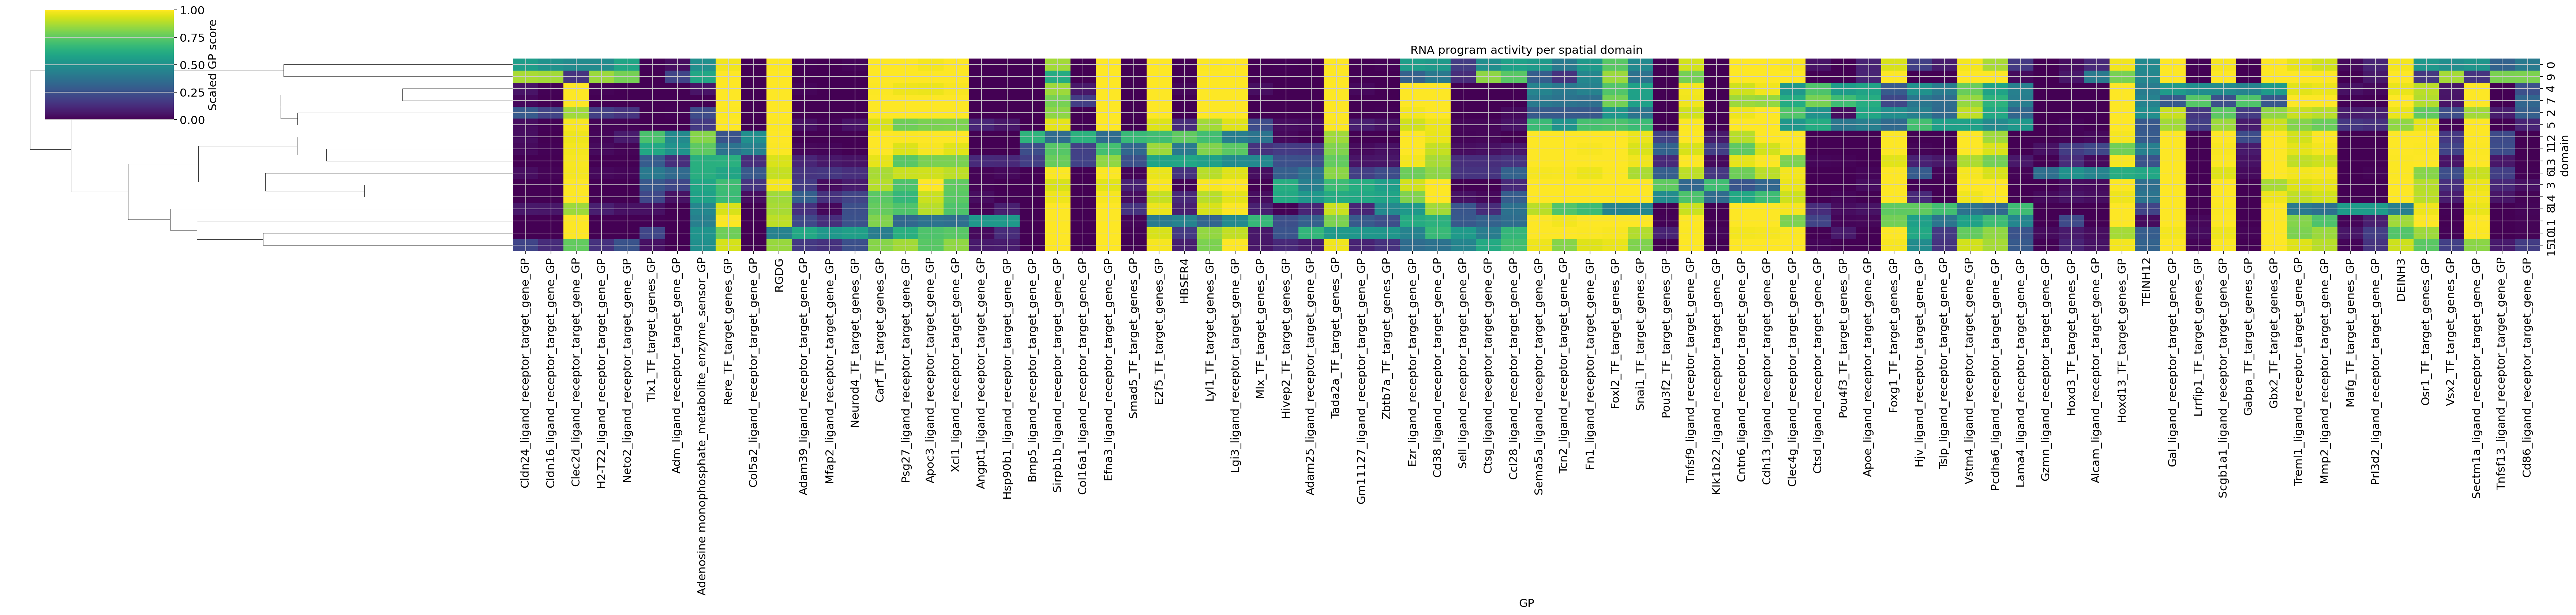

In [8]:
# Sign-corrected activity so positive = "high" in the colour map.
rna.obsm["X_storm_gp_plot"] = rna.obsm["X_storm_gp_signc"]

fig, rna_heatmap_df = gp_cluster_heatmap(
    rna,
    gp_indices=list(top_rna["gp_idx"]),
    gp_names=list(top_rna["gp_name"]),
    cluster_key="domain", gp_key="X_storm_gp_plot",
    cluster_order=domain_order, scale="minmax", row_cluster=True,
    title="RNA program activity per spatial domain",
)
fig.savefig(f"{GP_DIR}/rna_gp_domain_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

The ATAC heatmap answers the same question from the
chromatin-accessibility view. Programs that look similar across the two
modalities are supported by both transcription and accessibility; programs
that differ point to regulatory activity that one modality sees and the other
does not.

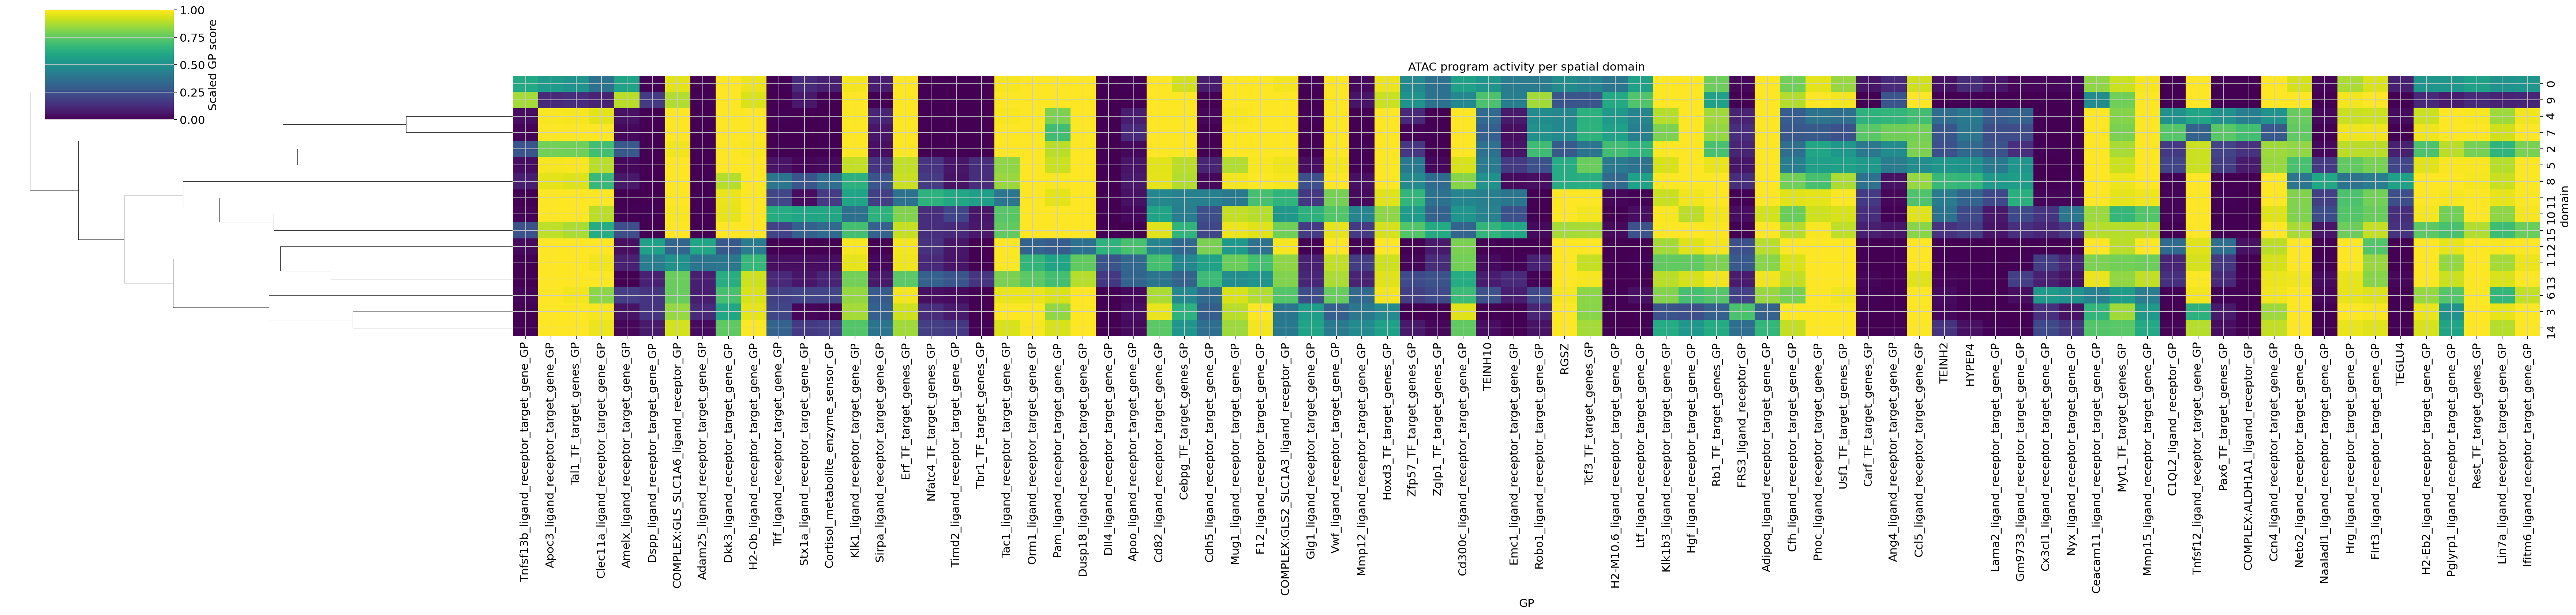

In [9]:
atac.obsm["X_storm_gp_plot"] = atac.obsm["X_storm_gp_signc"]

fig, atac_heatmap_df = gp_cluster_heatmap(
    atac,
    gp_indices=list(top_atac["gp_idx"]),
    gp_names=list(top_atac["gp_name"]),
    cluster_key="domain", gp_key="X_storm_gp_plot",
    cluster_order=domain_order, scale="minmax", row_cluster=True,
    title="ATAC program activity per spatial domain",
)
fig.savefig(f"{GP_DIR}/atac_gp_domain_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 7. Save the annotated AnnDatas and program tables

Persist the program-annotated AnnDatas and the shortlist tables. Tutorial 6
reads ``top_gps_rna.csv`` / ``top_gps_atac.csv`` (and the saved
``X_storm_gp``) to draw the weight-composition and spatial-activity figures
without re-encoding.

In [10]:
rna.write(f"{GP_DIR}/rna_gp.h5ad", compression="gzip")
atac.write(f"{GP_DIR}/atac_gp.h5ad", compression="gzip")
subset_rna.to_csv(f"{GP_DIR}/gp_summary_rna_active.csv", index=False)
subset_atac.to_csv(f"{GP_DIR}/gp_summary_atac_active.csv", index=False)
top_rna.to_csv(f"{GP_DIR}/top_gps_rna.csv", index=False)
top_atac.to_csv(f"{GP_DIR}/top_gps_atac.csv", index=False)
print("Wrote program-annotated AnnDatas + summary/top tables to", GP_DIR)

Wrote program-annotated AnnDatas + summary/top tables to ../artifacts/storm_tutorial/gp_analysis


## 8. Next steps

* [Tutorial 6 — GP visualisation](./tutorial_6_gp_visualization.ipynb) takes
  the top-program tables written above and draws the per-program weight
  composition bars, non-zero feature counts, and the spatial
  activity-across-timepoints panels.
* To explore a different shortlist, change ``TOP_GPS_PER_CLUSTER`` or sort
  ``top_gps_per_cluster`` by ``"abs_stat"`` (largest effect either way) or
  ``"corrected_p_value"`` (smallest FDR) instead of ``"rank_sum_stat"``.
* Point ``TRAINED_DILL`` at a full-length run to see programs that are sharper
  and more anatomically specific than a short demo checkpoint produces.